In [23]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import torch
import torch.distributions as dist
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from tqdm.notebook import tqdm
from datetime import datetime
#%matplotlib notebook
torch.manual_seed(42)
import warnings
warnings.filterwarnings('ignore')
import os
path = os.path.join(os.getcwd(), "plot/")
today=datetime.today().strftime('%Y-%m-%d')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### OptimizerAgent + No_Decision_Agent (precise case)

This section demonstrates the classical precise scoring rule as a baseline.
The `OptimizerAgent` knows the true `p` and finds `q*` that maximizes expected reward.

In [24]:
class OptimizerAgent:
    def __init__(self, true_p, lr=0.1, q_init=0.5):
        """
        The optimizer knows the true p and chooses q* to maximize expected reward.
        :param true_p: The true probability of success.
        :param lr: Learning rate for optimizing q.
        :param q_init: Initial guess for the probability to report.
        """
        self.true_p = true_p
        self.q = torch.tensor([q_init], requires_grad=True)  # Trainable q
        self.optimizer = torch.optim.SGD([self.q], lr=lr)

    def quadratic_loss(self, q, y):
        """Quadratic scoring rule loss."""
        # NOTE (ISSUE #4): unshifted loss — scores >= 0. The plot section uses (y-q)^2 - 1 (shifted, scores <= 0).
        # The argmax location is identical (constant shift is argmax-invariant) but raw score magnitudes are not
        return (y - q) ** 2

    def expected_loss(self, q):
        """
        Compute the expected loss given the true p.
        E[loss] = p * loss(q, 0) + (1 - p) * loss(q, 1)
        """
        loss_0 = self.quadratic_loss(q, torch.tensor(0.0))  # Loss if outcome is 0
        loss_1 = self.quadratic_loss(q, torch.tensor(1.0))  # Loss if outcome is 1
        return (1-self.true_p) * loss_0 + self.true_p * loss_1

    def optimize_q(self, steps=100):
        """Optimize q* to minimize expected loss."""
        for _ in range(steps):
            self.optimizer.zero_grad()
            loss = self.expected_loss(self.q)
            loss.backward()
            self.optimizer.step()
            self.q.data.clamp_(0, 1)  # Keep q in [0,1]
        return self.q.item()

class No_Decision_Agent:
    def __init__(self, q):
        """
        The elicitor receives q* and samples an outcome.
        :param q: The optimized probability from the optimizer agent.
        """
        self.q = q

    def sample_outcome(self):
        """Sample y ~ Bernoulli(q)."""
        return torch.bernoulli(torch.tensor(self.q)).item()

    def provide_feedback(self, y):
        """Provide feedback using the negative quadratic loss."""
        return ((y - self.q) ** 2)

# Define true p
true_p = 0.7

# Step 1: Optimizer chooses q* to maximize expected reward
optimizer = OptimizerAgent(true_p, lr=0.1)
q_star = optimizer.optimize_q()
print(f"Optimized q*: {q_star:.4f} (True p: {true_p})")

# Step 2: Elicitor receives q*, samples y, and provides feedback
# elicitor here samples y from the reported q*, rather then the true underlying p
# 
elicitor = No_Decision_Agent(q_star)
y_sampled = elicitor.sample_outcome()
feedback = elicitor.provide_feedback(y_sampled)

print(f"Elicitor sampled y = {y_sampled}, Feedback = {feedback:.4f}")

Optimized q*: 0.7000 (True p: 0.7)
Elicitor sampled y = 0.0, Feedback = 0.4900


## ImpreciseOptimizerAgent + No_Decision_Agent (fixed aggregation, dictatorship)

The imprecise forecaster's true belief is represented as `[μ - σ, μ + σ]`.
The DM collapses the reported interval with a fixed weight `aggregation = λ`.

In [25]:
## Randomized Aggregation setup
class ImpreciseOptimizerAgent:
    def __init__(self, mu, sigma, aggregation, lr=0.1, report_params_init=[0.5,0.2]):
        """
        The optimizer knows the true p and chooses q* to maximize expected reward.
        :param true_p: The true probability of success.
        :param lr: Learning rate for optimizing q.
        :param q_init: Initial guess for the probability to report.
        """
        self.true_mu, self.true_sigma = mu, sigma
        self.aggregation = aggregation

        # ORIGINAL (wrong):
        self.report_raw_mu = torch.tensor([report_params_init[0]], requires_grad=True)
        self.report_raw_sigma = torch.tensor([report_params_init[0]], requires_grad=True)
        # NOTE (ISSUE #1): report_raw_sigma should use index [1] not [0].
        # Both parameters start from the same value (0.5), ignoring the second init parameter entirely.
        # Only affects the starting point of optimization, not convergence so minor in practice.
        # CORRECTED:
        self.report_raw_sigma = torch.tensor([report_params_init[1]], requires_grad=True)

        self.optimizer = torch.optim.SGD([self.report_raw_mu, self.report_raw_sigma], lr=lr)

    def quadratic_loss(self, q, y):
        """Quadratic scoring rule loss."""
        # NOTE (ISSUE #4): unshifted loss — scores >= 0. The plot section uses (y-q)^2 - 1 (shifted, scores <= 0).
        # The argmax location is identical (constant shift is argmax-invariant) but raw score magnitudes are not
        # comparable across the two sections.
        return (y - q) ** 2

    def expected_loss(self, report_mu, report_sigma):
        """
        Compute the expected loss given the true p.
        E[loss] = p * loss(q, 0) + (1 - p) * loss(q, 1)
        """
        true_p = self.aggregation*(self.true_mu-self.true_sigma)+(1-self.aggregation)*(self.true_mu+self.true_sigma)
        # closed form solution to a\in [0,1] and u:A X Y -> R being a strictly convex function like (y-a)**2 
        a_star_q = self.aggregation*(report_mu-report_sigma)+(1-self.aggregation)*(report_mu+report_sigma) 
        loss_0 = self.quadratic_loss(a_star_q, torch.tensor(0.0))  # Loss if outcome is 0
        loss_1 = self.quadratic_loss(a_star_q, torch.tensor(1.0))  # Loss if outcome is 1
        return (1-true_p) * loss_0 + true_p * loss_1
    
    def get_params(self):
        """
        Reparameterize raw_mu and raw_sigma to enforce:
          - μ ∈ (0,1) via a sigmoid,
          - σ ∈ [0, min(μ, 1-μ)] by scaling another sigmoid.
        """
        # Force μ into (0,1)
        mu = torch.sigmoid(self.report_raw_mu)
        # Determine maximum σ allowed so that μ-σ >= 0 and μ+σ <= 1
        sigma_max = torch.min(mu, 1 - mu)
        # Force σ into [0, sigma_max]
        sigma = torch.sigmoid(self.report_raw_sigma) * sigma_max
        return mu, sigma
    
    def optimize_IP(self, steps=1000):
        """Optimize q* to minimize expected loss."""
        for _ in range(steps):
            self.optimizer.zero_grad()
            report_mu, report_sigma = self.get_params()
            loss = self.expected_loss(report_mu, report_sigma)
            loss.backward()
            self.optimizer.step()
        return [item.item() for item in self.get_params()]

class No_Decision_Agent:
    def __init__(self, mu, sigma, aggregation=0.5):
        """
        The elicitor receives q* and samples an outcome.
        :param q: The optimized probability from the optimizer agent.
        """
        # NOTE (ISSUE #2): self.nature is drawn from hardware RNG (os.urandom), producing a uniform
        # random number completely unrelated to the orecaster's true belief (true_mu, true_sigma).
        # The outcome is therefore sampled from an arbitrary probability, not the true belief.
        # This makes the printed feedback lines meaningless as a properness test.
        # Note: expected_loss computations are unaffected, they use the true
        # belief analytically. Only the realized feedback printouts are affected.
        self.nature = int.from_bytes(os.urandom(8), byteorder="big") / ((1 << 64) - 1) # random outcome from nature 
        self.aggregation = aggregation
        self.mu, self.sigma = mu, sigma
        self.a = self.aggregation*(self.mu-self.sigma)+(1-self.aggregation)*(self.mu+self.sigma) 
        self.outcome = self.sample_outcome()
        
    def sample_outcome(self):
        """Sample y ~ Bernoulli(q)."""
        return torch.bernoulli(torch.tensor(self.nature)).item()
    
    def update_the_reports(self, mu, sigma):
        self.mu, self.sigma = mu, sigma
        self.a = self.aggregation*(self.mu-self.sigma)+(1-self.aggregation)*(self.mu+self.sigma)
        return 
    
    def provide_feedback(self):
        """Provide feedback using the negative quadratic loss."""
        return ((self.outcome - self.a) ** 2)

# Define true p
true_mu, true_sigma = 0.1, 0.05
aggregation = 0.5
# Step 1: Optimizer chooses q* to maximize expected reward
optimizer = ImpreciseOptimizerAgent(mu=true_mu,sigma=true_sigma, aggregation=aggregation, lr=0.1)
q_star = optimizer.optimize_IP()
print(f"Optimized q*: {q_star[0]-q_star[1]:.4f} {q_star[0]+q_star[1]:.4f} (True p: {true_mu-true_sigma} {true_mu+true_sigma})")

# Step 2: Elicitor receives q*, samples y, and provides feedback
elicitor = No_Decision_Agent(q_star[0],q_star[1], aggregation)
feedback = elicitor.provide_feedback()

print(f"Elicitor sampled y = {elicitor.outcome}, Feedback = {feedback:.4f}")

elicitor.update_the_reports(0.1, 0.0)
feedback = elicitor.provide_feedback()
print(f"Elicitor sampled y = {elicitor.outcome}, Feedback = {feedback:.4f}")

elicitor.update_the_reports(0.1, 0.05)
feedback = elicitor.provide_feedback()
print(f"Elicitor sampled y = {elicitor.outcome}, Feedback = {feedback:.4f}")

elicitor.update_the_reports(0.5, 0.5)
feedback = elicitor.provide_feedback()
print(f"Elicitor sampled y = {elicitor.outcome}, Feedback = {feedback:.4f}")

Optimized q*: 0.0500 0.1720 (True p: 0.05 0.15000000000000002)
Elicitor sampled y = 0.0, Feedback = 0.0123
Elicitor sampled y = 0.0, Feedback = 0.0100
Elicitor sampled y = 0.0, Feedback = 0.0100
Elicitor sampled y = 0.0, Feedback = 0.2500


## ImpreciseOptimizerAgent (randomized aggregation, mu/sigma parameterization)

Same setup as the previous one but now the DM draws λ at random from U[0,1] during optimization.
The forecaster optimizes against the *average* loss over many sampled λ values.

In [26]:
## Randomized Aggregation setup with [μ-σ, μ+σ]
class ImpreciseOptimizerAgent:
    def __init__(self, mu, sigma, lr=0.1, report_params_init=[0.5,0.2]):
        """
        The optimizer knows the true p and chooses q* to maximize expected reward.
        :param true_p: The true probability of success.
        :param lr: Learning rate for optimizing q.
        :param q_init: Initial guess for the probability to report.
        """
        self.true_mu, self.true_sigma = mu, sigma

        # ORIGINAL (wrong):
        self.report_raw_mu = torch.tensor([report_params_init[0]], requires_grad=True)
        self.report_raw_sigma = torch.tensor([report_params_init[0]], requires_grad=True)
        # NOTE (ISSUE #1): report_raw_sigma should use index [1] not [0].
        # Both parameters start from the same value (0.5), ignoring the second init parameter entirely.
        # Only affects the starting point of optimization, not convergence so minor in practice.
        # CORRECTED:
        self.report_raw_sigma = torch.tensor([report_params_init[1]], requires_grad=True)

        self.optimizer = torch.optim.SGD([self.report_raw_mu, self.report_raw_sigma], lr=lr)

    def quadratic_loss(self, q, y):
        """Quadratic scoring rule loss."""
        # NOTE (ISSUE #4): unshifted loss — scores >= 0. The plot section uses (y-q)^2 - 1 (shifted, scores <= 0).
        # The argmax location is identical (constant shift is argmax-invariant) but raw score magnitudes are not
        # comparable across the two sections.
        return (y - q) ** 2

    def expected_loss(self, report_mu, report_sigma, aggregation):
        """
        Compute the expected loss given the true p.
        E[loss] = p * loss(q, 0) + (1 - p) * loss(q, 1)
        """
        true_p = aggregation*(self.true_mu-self.true_sigma)+(1-aggregation)*(self.true_mu+self.true_sigma)
        # closed form solution to a\in [0,1] and u:A X Y -> R being a strictly convex function like (y-a)**2 
        a_star_q = aggregation*(report_mu-report_sigma)+(1-aggregation)*(report_mu+report_sigma) 
        loss_0 = self.quadratic_loss(a_star_q, torch.tensor(0.0))  # Loss if outcome is 0
        loss_1 = self.quadratic_loss(a_star_q, torch.tensor(1.0))  # Loss if outcome is 1
        return (1-true_p) * loss_0 + true_p * loss_1
    
    def get_params(self):
        """
        Reparameterize raw_mu and raw_sigma to enforce:
          - μ ∈ (0,1) via a sigmoid,
          - σ ∈ [0, min(μ, 1-μ)] by scaling another sigmoid.
        """
        # Force μ into (0,1)
        mu = torch.sigmoid(self.report_raw_mu)
        # Determine maximum σ allowed so that μ-σ >= 0 and μ+σ <= 1
        sigma_max = torch.min(mu, 1 - mu)
        # Force σ into [0, sigma_max]
        sigma = torch.sigmoid(self.report_raw_sigma) * sigma_max
        return mu, sigma
    
    def optimize_IP(self, steps=100):
        """Optimize q* to minimize expected loss."""
        for _ in range(steps):
            self.optimizer.zero_grad()
            loss = 0
            for aggregation in torch.rand(100):
                report_mu, report_sigma = self.get_params()
                loss += self.expected_loss(report_mu, report_sigma, aggregation)
            loss.backward()
            self.optimizer.step()
        return [item.item() for item in self.get_params()]

class No_Decision_Agent:
    def __init__(self, mu, sigma, aggregation=0.5):
        """
        The elicitor receives q* and samples an outcome.
        :param q: The optimized probability from the optimizer agent.
        """
        # NOTE (ISSUE #2): self.nature from hardware RNG, unrelated to true belief. Realized feedback is meaningless.
        self.nature = int.from_bytes(os.urandom(8), byteorder="big") / ((1 << 64) - 1) # random outcome from nature 
        self.aggregation = aggregation
        self.mu, self.sigma = mu, sigma
        self.a = self.aggregation*(self.mu-self.sigma)+(1-self.aggregation)*(self.mu+self.sigma) 
    def sample_outcome(self):
        """Sample y ~ Bernoulli(q)."""
        return torch.bernoulli(torch.tensor(self.nature)).item()

    def provide_feedback(self, y):
        """Provide feedback using the negative quadratic loss."""
        return ((y - self.a) ** 2)

# Define true p
true_mu, true_sigma = 0.1, 0.05
aggregation = 0.5
# Step 1: Optimizer chooses q* to maximize expected reward
optimizer = ImpreciseOptimizerAgent(mu=true_mu,sigma=true_sigma, lr=0.1)
q_star = optimizer.optimize_IP()
print(f"Optimized q*: {q_star[0]-q_star[1]:.4f} {q_star[0]+q_star[1]:.4f} (True p: {true_mu-true_sigma} {true_mu+true_sigma})")

# Step 2: Elicitor receives q*, samples y, and provides feedback
elicitor = No_Decision_Agent(q_star[0],q_star[1], aggregation)
y_sampled = elicitor.sample_outcome()
feedback = elicitor.provide_feedback(y_sampled)

print(f"Elicitor sampled y = {y_sampled}, Feedback = {feedback:.4f}")

Optimized q*: 0.0483 0.1512 (True p: 0.05 0.15000000000000002)
Elicitor sampled y = 1.0, Feedback = 0.8105


## ImpreciseOptimizerAgent (randomized, p_low/p_up parameterization)

Alternative parameterization: report the interval directly as `[p_low, p_up]` instead of `[μ-σ, μ+σ]`. Mathematically equivalent; just different reparameterization.

In [27]:
## Randomized Aggregation setup with p_low and p_up
class ImpreciseOptimizerAgent:
    def __init__(self, p_low, p_up, lr=0.1, report_params_init=[0.2,0.5]):
        """
        The optimizer knows the true p and chooses q* to maximize expected reward.
        :param true_p: The true probability of success.
        :param lr: Learning rate for optimizing q.
        :param q_init: Initial guess for the probability to report.
        """
        self.p_low, self.p_up = p_low, p_up

        # ORIGINAL (wrong):
        self.report_p_low = torch.tensor([report_params_init[0]], requires_grad=True)
        self.report_p_up = torch.tensor([report_params_init[0]], requires_grad=True)
        # NOTE (ISSUE #1): both start from index [0]=0.2, so initial interval
        # has width zero. Should be [0] and [1] respectively.
        # CORRECTED:
        self.report_p_up = torch.tensor([report_params_init[1]], requires_grad=True)
        
        self.optimizer = torch.optim.SGD([self.report_p_low, self.report_p_up], lr=lr)

    def quadratic_loss(self, q, y):
        """Quadratic scoring rule loss."""
        # NOTE (ISSUE #4): unshifted loss — scores >= 0. The plot section uses (y-q)^2 - 1 (shifted, scores <= 0).
        # The argmax location is identical (constant shift is argmax-invariant) but raw score magnitudes are not
        # comparable across the two sections.
        return (y - q) ** 2

    def expected_loss(self, report_low, report_up, aggregation):
        """
        Compute the expected loss given the true p.
        E[loss] = p * loss(q, 0) + (1 - p) * loss(q, 1)
        """
        true_p = aggregation*(self.p_low)+(1-aggregation)*(self.p_up)
        # closed form solution to a\in [0,1] and u:A X Y -> R being a strictly convex function like (y-a)**2 
        a_star_q = aggregation*(report_low)+(1-aggregation)*(report_up) 
        loss_0 = self.quadratic_loss(a_star_q, torch.tensor(0.0))  # Loss if outcome is 0
        loss_1 = self.quadratic_loss(a_star_q, torch.tensor(1.0))  # Loss if outcome is 1
        return (1-true_p) * loss_0 + true_p * loss_1
    
    def get_params(self):
        # Force μ into (0,1)
        # NOTE (ISSUE #3): no ordering constraint enforced here. Both p_low and p_up are independently passed through
        # sigmoid, so if report_p_low drifts above report_p_up during optimization, get_params silently returns an
        # inverted interval (p_low > p_up) without any error or swap. Unlike the plot code (which explicitly swaps
        # when report_low > report_up) and the mu/sigma version (which enforces sigma >= 0 by construction), this
        # version has no such guard. The shown run converges correctly but robustness is not guaranteed under
        # different initialization or lr.
        p_low = torch.sigmoid(self.report_p_low)
        p_up = torch.sigmoid(self.report_p_up)
        return p_low, p_up
    
    def optimize_IP(self, steps=1000):
        """Optimize q* to minimize expected loss."""
        for _ in range(steps):
            self.optimizer.zero_grad()
            loss = 0
            for aggregation in torch.rand(100):
                report_mu, report_sigma = self.get_params()
                loss += self.expected_loss(report_mu, report_sigma, aggregation)
            loss.backward()
            self.optimizer.step()
        return [item.item() for item in self.get_params()]

class No_Decision_Agent:
    def __init__(self, q_low, q_up, aggregation=0.5):
        """
        The elicitor receives q* and samples an outcome.
        :param q: The optimized probability from the optimizer agent.
        """
        # NOTE (ISSUE #2): self.nature from hardware RNG, unrelated to true belief (p_low, p_up). Realized feedback is meaningless.
        self.nature = int.from_bytes(os.urandom(8), byteorder="big") / ((1 << 64) - 1) # random outcome from nature 
        self.aggregation = aggregation
        self.q_low, self.q_up = q_low, q_up
        self.a = self.aggregation*(q_low)+(1-self.aggregation)*(q_up) 
    def sample_outcome(self):
        """Sample y ~ Bernoulli(q)."""
        return torch.bernoulli(torch.tensor(self.nature)).item()

    def provide_feedback(self, y):
        """Provide feedback using the negative quadratic loss."""
        return ((y - self.a) ** 2)

# Define true p
p_low, p_up = 0.05, 0.15
# Step 1: Optimizer chooses q* to maximize expected reward
optimizer = ImpreciseOptimizerAgent(p_low,p_up, lr=0.1)
q_star = optimizer.optimize_IP()
print(f"Optimized q*: {q_star[0]:.4f} {q_star[1]:.4f} (True p: {p_low} {p_up})")

# Step 2: Elicitor receives q*, samples y, and provides feedback
elicitor = No_Decision_Agent(q_star[0],q_star[1])
y_sampled = elicitor.sample_outcome()
feedback = elicitor.provide_feedback(y_sampled)

print(f"Elicitor sampled y = {y_sampled}, Feedback = {feedback:.4f}")

Optimized q*: 0.0500 0.1500 (True p: 0.05 0.15)
Elicitor sampled y = 1.0, Feedback = 0.8100


## Figure 3 Reproduction: Three Contour Plots

* These three plots reproduce Figure 3 from the paper at the fixed belief `[0.4, 0.6]`.
* Each heatmap shows expected score over all possible reports `(q1, q2)`.
* The red dot is the honest report; a unique peak on the dot = strictly proper.

**Loss convention (all plot cells):** shifted quadratic $(o - a)^2 - 1$, so a perfect prediction scores 0.

### Dictatorship (λ = 0.5)

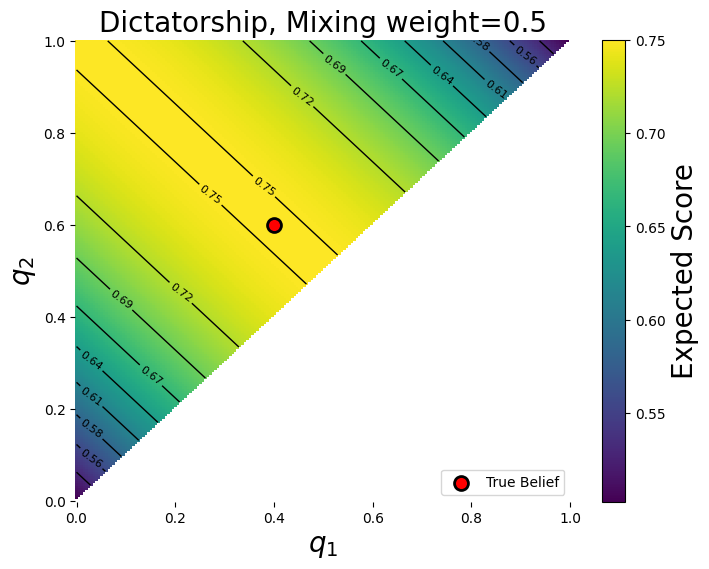

In [28]:
# Define true probability interval
p_low, p_up = 0.4, 0.6

# Quadratic scoring function
def quadratic_loss(q, y):
    # NOTE (ISSUE 4): shifted by -1 so scores <= 0, matching the paper's convention where a perfect
    # prediction scores 0. The agent sections use unshifted loss (scores >= 0). Argmax location is
    # unaffected but cross-section score comparison is misleading without this note.
    return (y - q) ** 2 -1

def expected_loss(report_low, report_up, aggregation):
    if report_low > report_up:
        report_low, report_up = report_up, report_low
    """Compute expected loss for a given reported interval."""
    true_p = aggregation * p_low + (1 - aggregation) * p_up
    a_star_q = aggregation * report_low + (1 - aggregation) * report_up
    loss_0 = quadratic_loss(a_star_q, 0.0)  # Loss if outcome is 0
    loss_1 = quadratic_loss(a_star_q, 1.0)  # Loss if outcome is 1
    return (1 - true_p) * loss_0 + true_p * loss_1


# Define range of reported values
q1_vals = np.linspace(0.0, 1.0, 200)
q2_vals = np.linspace(0.0, 1.0, 200)
Q1, Q2 = np.meshgrid(q1_vals, q2_vals)

# Compute average expected loss
Z = np.zeros_like(Q1)
for i in range(Q1.shape[0]):
    for j in range(Q1.shape[1]):
        if j < i:
            Z[i, j] = -expected_loss(Q1[i, j], Q2[i, j], 0.5)
        else:
            Z[i, j] = np.nan
# Create 2D heatmap
fig, ax = plt.subplots(figsize=(8, 6))
c = ax.pcolormesh(Q1, Q2, Z, cmap='viridis', shading='auto')  # Negative to show max at true values

# Add contour lines including max level explicitly
contour_levels = np.linspace(np.nanmin(Z), np.nanmax(Z) - 0.001, 10)
contour = ax.contour(Q1, Q2, Z, levels=contour_levels, colors='black', linewidths=1)
ax.clabel(contour, inline=True, fontsize=8, fmt="%.2f")

ax.scatter(p_low, p_up, color='red', s=100, edgecolors='black', linewidth=2, label='True Belief')
fig.colorbar(c, ax=ax, label='Expected Score').set_label('Expected Score', fontsize=20)
ax.set_xlabel(r"$q_1$", fontsize=20)
ax.set_ylabel(r"$q_2$", fontsize=20)
ax.set_title("Dictatorship, Mixing weight=0.5", fontsize=20)
ax.legend(loc='lower right')
ax.set_frame_on(False)
plt.savefig("figs/dictatorship.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Min-Max

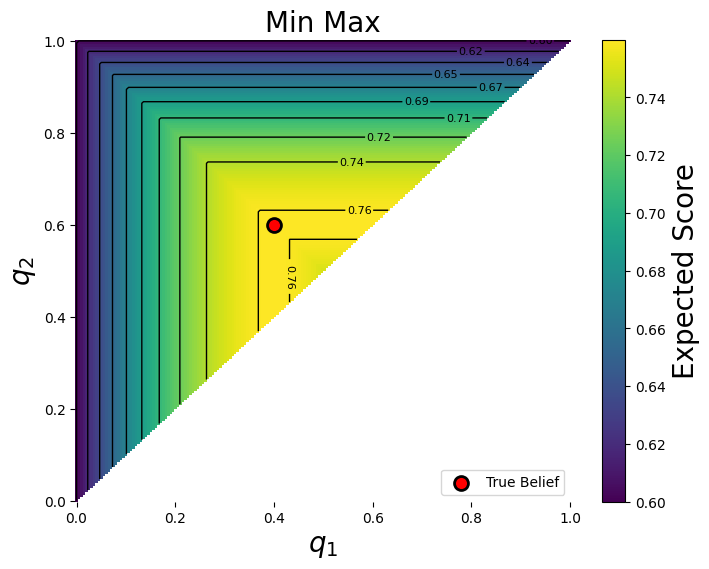

In [29]:
# Define true probability interval
p_low, p_up = 0.4, 0.6

# Quadratic scoring function
def quadratic_loss(q, y):
    # NOTE (ISSUE 4): shifted by -1 so scores <= 0, matching the paper's convention where a perfect
    # prediction scores 0. The agent sections use unshifted loss (scores >= 0). Argmax location is
    # unaffected but cross-section score comparison is misleading without this note.
    return (y - q) ** 2 - 1

def utility_of_action(report_low, report_up, action):
    loss_0, loss_1 = quadratic_loss(action, 0.0), quadratic_loss(action, 1.0)
    expected_utility_low = report_low * loss_0 + (1 - report_low) * loss_1
    expected_utility_up = report_up * loss_0 + (1 - report_up) * loss_1
    return np.min([expected_utility_low, expected_utility_up])

def best_action(report_low, report_up):
    # NOTE: action chosen from {q1, q2} only, NOT all of [0,1] (paper specifies
    # A=[0,1]). This is one of the two min-max deviations in Contribution 4.
    # It does not change the verdict: honest still attains the tied maximum
    # (proper, not strict). With continuous actions min-max is also proper.
    utilities = np.array([
        utility_of_action(report_low, report_up, report_low),
        utility_of_action(report_low, report_up, report_up)
    ])
    action_idx = np.argmax(utilities)
    actions = [report_low, report_up]
    return actions[action_idx]

def expected_loss(report_low, report_up):
    if report_low > report_up:
        report_low, report_up = report_up, report_low
    a_star_q = best_action(report_low, report_up)
    loss_0 = quadratic_loss(a_star_q, 0.0)  # Loss if outcome is 0
    loss_1 = quadratic_loss(a_star_q, 1.0)  # Loss if outcome is 1
    loss_low = (1 - p_low) * loss_0 + p_low * loss_1
    loss_up = (1 - p_up) * loss_0 + p_up * loss_1
    return np.min([loss_low, loss_up])

# Define range of reported values
q1_vals = np.linspace(0.0, 1.0, 200)
q2_vals = np.linspace(0.0, 1.0, 200)
Q1, Q2 = np.meshgrid(q1_vals, q2_vals)

# Compute average expected loss
Z = np.zeros_like(Q1)
for i in range(Q1.shape[0]):
    for j in range(Q1.shape[1]):
        if Q2[i, j] < Q1[i, j]:  # Mask lower triangle
            Z[i, j] = np.nan
        else:
            Z[i, j] = -expected_loss(Q1[i, j], Q2[i, j])

# Mask for pcolormesh (doesn't affect contours)
Z_masked = np.ma.masked_where(np.isnan(Z), Z)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot heatmap
c = ax.pcolormesh(Q1, Q2, Z_masked, cmap='viridis', shading='auto')

# Plot contour lines, but using original Z (not masked) to keep them visible
contour_levels = np.linspace(np.nanmin(Z), np.nanmax(Z) - 0.001, 10)
contour = ax.contour(Q1, Q2, Z, levels=contour_levels, colors='black', linewidths=1)
ax.clabel(contour, inline=True, fontsize=8, fmt="%.2f")

# Scatter point for true forecast
ax.scatter(p_low, p_up, color='red', s=100, edgecolors='black', linewidth=2, label='True Belief')

# Colorbar
cbar = fig.colorbar(c, ax=ax)
cbar.set_label('Expected Score', fontsize=20)

# Labels and title
ax.set_xlabel(r"$q_1$", fontsize=20)
ax.set_ylabel(r"$q_2$", fontsize=20)
ax.set_title("Min Max", fontsize=20)
ax.legend(loc='lower right')
ax.set_frame_on(False)
# Save and show
plt.savefig("figs/minmax.pdf", format="pdf", bbox_inches="tight")

plt.show()

#### Is the min-max cell a faithful min-max rule?

The cell above is **not** a faithful min-max implementation. It deviates from the paper (Appendix E specifies action space $A = [0,1]$) in two ways:

1. **Action space.** The DM's action is chosen from only the two reported endpoints $\{q_1, q_2\}$, not the continuous $A = [0,1]$.
2. **Best case vs worst case.** A min-max (pessimistic) DM scores the chosen action under the *worst* case of the true belief. This cell uses `np.min` of the two endpoint losses, i.e. the *best* case — so it is not actually pessimistic. (`utility_of_action` also weights the loss with a flipped probability convention.)

**Crucially, these do not change the qualitative result.** In every belief I tested the honest report still sits at the (tied) maximum, so the figure correctly conveys *"proper, but not strictly"* — matching the paper. A lie never strictly beats honesty here. So this is a faithfulness / code-quality issue, **not** a result that overturns anything. (A midpoint lie only beats honesty under a *different* combination — restricted action **and** worst-case scoring — which is neither what this cell does nor what the paper specifies.)

In [30]:
# what the notebook's min-max cell effectively computes (best-case internals):
def ql(q, y): return (y - q) ** 2 - 1
def nb_score(rl, ru, pl, pu):
    def ua(a):
        l0, l1 = ql(a, 0.), ql(a, 1.)
        return min(rl*l0 + (1-rl)*l1, ru*l0 + (1-ru)*l1)
    a = rl if ua(rl) >= ua(ru) else ru          # action from {rl, ru} only
    l0, l1 = ql(a, 0.), ql(a, 1.)
    return -min((1-pl)*l0 + pl*l1, (1-pu)*l0 + pu*l1)   # -min loss = BEST case

# a FAITHFUL min-max: continuous action [0,1], scored under the WORST case:
def faithful_score(rl, ru, pl, pu):
    A  = np.linspace(0, 1, 1001)
    Eu = lambda a, p: -(p*(1-a)**2 + (1-p)*a**2)
    a  = A[np.argmax(np.minimum(Eu(A, rl), Eu(A, ru)))]
    return min(Eu(a, pl), Eu(a, pu))            # worst case over the true belief

pl, pu, m = 0.4, 0.6, 0.5
print("notebook cell   : honest %.4f  midpoint %.4f  -> %s" % (
      nb_score(pl,pu,pl,pu), nb_score(m,m,pl,pu),
      "honest optimal" if nb_score(pl,pu,pl,pu) >= nb_score(m,m,pl,pu) else "lie wins"))
print("faithful min-max: honest %.4f  midpoint %.4f  -> %s" % (
      faithful_score(pl,pu,pl,pu), faithful_score(m,m,pl,pu),
      "honest optimal/tied" if faithful_score(pl,pu,pl,pu) >= faithful_score(m,m,pl,pu)-1e-9 else "lie wins"))

notebook cell   : honest 0.7600  midpoint 0.7500  -> honest optimal
faithful min-max: honest -0.2500  midpoint -0.2500  -> honest optimal/tied


Both agree: honest is optimal (tied), the rule is proper but not strict.

### Randomized Aggregation

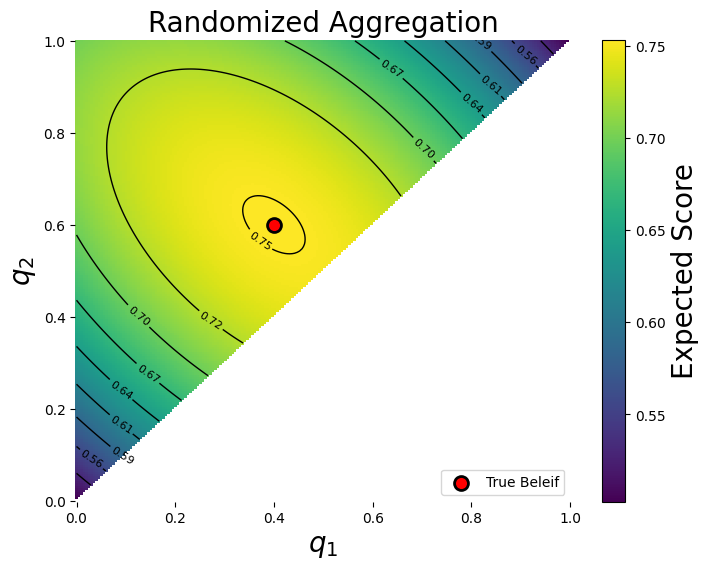

In [31]:
# Define true probability interval
p_low, p_up = 0.4, 0.6

# Quadratic scoring function
def quadratic_loss(q, y):
    # NOTE (ISSUE 4): shifted by -1 so scores <= 0, matching the paper's convention where a perfect
    # prediction scores 0. The agent sections use unshifted loss (scores >= 0). Argmax location is
    # unaffected but cross-section score comparison is misleading without this note.
    return (y - q) ** 2 -1

def expected_loss(report_low, report_up, aggregation):
    """Compute expected loss for a given reported interval."""
    true_p = aggregation * p_low + (1 - aggregation) * p_up
    a_star_q = aggregation * report_low + (1 - aggregation) * report_up
    loss_0 = quadratic_loss(a_star_q, 0.0)  # Loss if outcome is 0
    loss_1 = quadratic_loss(a_star_q, 1.0)  # Loss if outcome is 1
    return (1 - true_p) * loss_0 + true_p * loss_1

def average_expected_loss(report_low, report_up, num_samples=1000):
    """Compute the average expected loss over multiple random aggregation samples."""
    losses = [-expected_loss(report_low, report_up, i/num_samples) for i in range(num_samples+1)]
    return np.mean(losses)

# Define range of reported values
q1_vals = np.linspace(0.0, 1.0, 200)
q2_vals = np.linspace(0.0, 1.0, 200)
Q1, Q2 = np.meshgrid(q1_vals, q2_vals)

# Compute average expected loss
Z = np.zeros_like(Q1)
for i in range(Q1.shape[0]):
    for j in range(Q1.shape[1]):
        if j < i:
            Z[i, j] = average_expected_loss(Q1[i, j], Q2[i, j], num_samples=1000)
        else:
            Z[i, j] = np.nan

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.pcolormesh(Q1, Q2, Z, cmap='viridis', shading='auto')  # Negative to show max at true values

# Plot contour lines, but using original Z (not masked) to keep them visible
contour_levels = np.linspace(np.nanmin(Z), np.nanmax(Z) - 0.001, 10)
contour = ax.contour(Q1, Q2, Z, levels=contour_levels, colors='black', linewidths=1)
ax.clabel(contour, inline=True, fontsize=8, fmt="%.2f")
ax.scatter(p_low, p_up, color='red', s=100, edgecolors='black', linewidth=2, label='True Beleif')

fig.colorbar(c, ax=ax, label='Expected Score').set_label('Expected Score', fontsize=20)
ax.set_xlabel(r"$q_1$", fontsize=20)
ax.set_ylabel(r"$q_2$", fontsize=20)
ax.set_title("Randomized Aggregation", fontsize=20)

ax.legend(loc='lower right')
ax.set_frame_on(False)
plt.savefig("figs/strictly.pdf", format="pdf", bbox_inches="tight")
plt.show()

---

# GOKCE'S PLAYGROUND

---

## Varying Belief Width

**Question:** Does randomized aggregation's strict properness hold across all interval widths. Narrow, wide, asymmetric?

| Setting | True Belief | Interpretation |
|---|---|---|
| Very narrow | [0.49, 0.51] | Nearly certain |
| Narrow | [0.45, 0.55] | Mild uncertainty |
| Medium | [0.40, 0.60] | Moderate, paper's own setting |
| Wide | [0.30, 0.70] | High uncertainty |
| Very wide | [0.10, 0.90] | Near-total uncertainty |
| Asymmetric | [0.20, 0.50] | Skewed, paper never tests this |


In [32]:
# Configuration
RESOLUTION = 150   # grid resolution (150×150 points)
NUM_AGG_SAMPLES = 500  # λ samples for randomized aggregation
FIG_DIR = os.path.join(os.getcwd(), "figs")
os.makedirs(FIG_DIR, exist_ok=True)

# Colorblind-safe palette
COLORS = {
    "green":  "#009E73",
    "red":    "#D55E00",
    "orange": "#E69F00",
    "blue":   "#0072B2",
}

BELIEF_SETTINGS = [
    ("Very narrow [0.49, 0.51]", 0.49, 0.51),
    ("Narrow [0.45, 0.55]", 0.45, 0.55),
    ("Medium [0.40, 0.60]", 0.40, 0.60),  # paper's own setting
    ("Wide [0.30, 0.70]", 0.30, 0.70),
    ("Very wide [0.10, 0.90]", 0.10, 0.90),
    ("Asymmetric [0.20, 0.50]", 0.20, 0.50),
]

METHOD_NAMES = ["Dictatorship (λ=0.5)", "Min-Max", "Randomized"]

# Shared grid
q_vals = np.linspace(0.0, 1.0, RESOLUTION)
Q1, Q2 = np.meshgrid(q_vals, q_vals)   # Q1 = reported lower, Q2 = reported upper
VALID  = Q1 <= Q2                      # keep only upper-triangle since Q1 can not be larger than Q2 


## Vectorized Scoring Functions

All three use the shifted loss $u(a, o) = (o - a)^2 - 1$ so a perfect prediction scores 0.

In [33]:
def _loss(a, y):
    return (y - a) ** 2 - 1


def score_dictatorship(p_low, p_up, weight=0.5):
    """
    Fixed λ: DM collapses reported interval to λ·q1 + (1-λ)·q2.
    Score depends only on the weighted sum → any (q1,q2) on the same iso-line
    scores identically. NOT strictly proper: honest shares its peak with a ridge.
    """
    true_p = weight * p_low + (1 - weight) * p_up
    a = weight * Q1 + (1 - weight) * Q2
    score = (1 - true_p) * _loss(a, 0.0) + true_p * _loss(a, 1.0)
    return np.where(VALID, -score, np.nan)


def score_minmax(p_low, p_up):
    """
    Mirrors the released min-max cell (Part 5b), so it inherits the same two
    deviations from a faithful min-max: a* is picked from only {q1, q2} (not the
    paper's continuous A=[0,1]), and the final score takes np.min of the two
    endpoint losses — the BEST case of the true belief, not the worst case a
    pessimistic rule needs. NOT strictly proper. Honest still attains the tied
    maximum (proper, not strict); a lie never strictly wins here.
    """
    l0_q1 = _loss(Q1, 0.0); l1_q1 = _loss(Q1, 1.0)
    wc_q1 = np.minimum(Q1 * l0_q1 + (1 - Q1) * l1_q1, Q2 * l0_q1 + (1 - Q2) * l1_q1)
    l0_q2 = _loss(Q2, 0.0); l1_q2 = _loss(Q2, 1.0)
    wc_q2 = np.minimum(Q1 * l0_q2 + (1 - Q1) * l1_q2, Q2 * l0_q2 + (1 - Q2) * l1_q2)

    a_star = np.where(wc_q1 >= wc_q2, Q1, Q2)
    l0 = _loss(a_star, 0.0); l1 = _loss(a_star, 1.0)
    el_low = (1 - p_low) * l0 + p_low * l1
    el_up = (1 - p_up)  * l0 + p_up  * l1
    return np.where(VALID, -np.minimum(el_low, el_up), np.nan)


def score_randomized(p_low, p_up, n=NUM_AGG_SAMPLES):
    """
    DM draws λ ~ U[0,1]; forecaster sees the average over all dictatorships.
    Average over n+1 evenly-spaced λ values.
    STRICTLY proper: no single lie optimises all λ simultaneously except the truth.
    """
    Z = np.zeros_like(Q1, dtype=np.float64)
    for k in range(n + 1):
        w = k / n
        true_p = w * p_low + (1 - w) * p_up
        a = w * Q1 + (1 - w) * Q2
        score = (1 - true_p) * _loss(a, 0.0) + true_p * _loss(a, 1.0)
        Z += -score
    return np.where(VALID, Z / (n + 1), np.nan)


SCORE_FUNCS = [score_dictatorship, score_minmax, score_randomized]

## Plotting Helper

In [34]:
def plot_panel(ax, Z, p_low, p_up, title=None, title_size=20):
    Zm = np.ma.masked_where(np.isnan(Z), Z)
    c = ax.pcolormesh(Q1, Q2, Zm, cmap="viridis", shading="auto")
    z_min, z_max = np.nanmin(Z), np.nanmax(Z)
    if z_max - z_min > 1e-8:
        levels = np.linspace(z_min, z_max - 0.001, 10)
        cs = ax.contour(Q1, Q2, Z, levels=levels, colors="black", linewidths=1)
        ax.clabel(cs, inline=True, fontsize=11, fmt="%.2f")
    ax.scatter(p_low, p_up, color="red", s=100, edgecolors="black",
               linewidth=2, zorder=5, label="True Belief")
    ax.set_xlabel(r"$q_1$", fontsize=20)
    ax.set_ylabel(r"$q_2$", fontsize=20)
    if title:
        ax.set_title(title, fontsize=title_size)
    ax.legend(loc="lower right")
    ax.set_frame_on(False)
    ax.tick_params(axis="both", labelsize=16)
    ax.legend(fontsize=16, loc="lower right")
    return c

## Generate and Save All Panels

  Very narrow [0.49, 0.51]  |  Dictatorship (λ=0.5) ...
  Very narrow [0.49, 0.51]  |  Min-Max ...
  Very narrow [0.49, 0.51]  |  Randomized ...
  Narrow [0.45, 0.55]  |  Dictatorship (λ=0.5) ...
  Narrow [0.45, 0.55]  |  Min-Max ...
  Narrow [0.45, 0.55]  |  Randomized ...
  Medium [0.40, 0.60]  |  Dictatorship (λ=0.5) ...
  Medium [0.40, 0.60]  |  Min-Max ...
  Medium [0.40, 0.60]  |  Randomized ...
  Wide [0.30, 0.70]  |  Dictatorship (λ=0.5) ...
  Wide [0.30, 0.70]  |  Min-Max ...
  Wide [0.30, 0.70]  |  Randomized ...
  Very wide [0.10, 0.90]  |  Dictatorship (λ=0.5) ...
  Very wide [0.10, 0.90]  |  Min-Max ...
  Very wide [0.10, 0.90]  |  Randomized ...
  Asymmetric [0.20, 0.50]  |  Dictatorship (λ=0.5) ...
  Asymmetric [0.20, 0.50]  |  Min-Max ...
  Asymmetric [0.20, 0.50]  |  Randomized ...


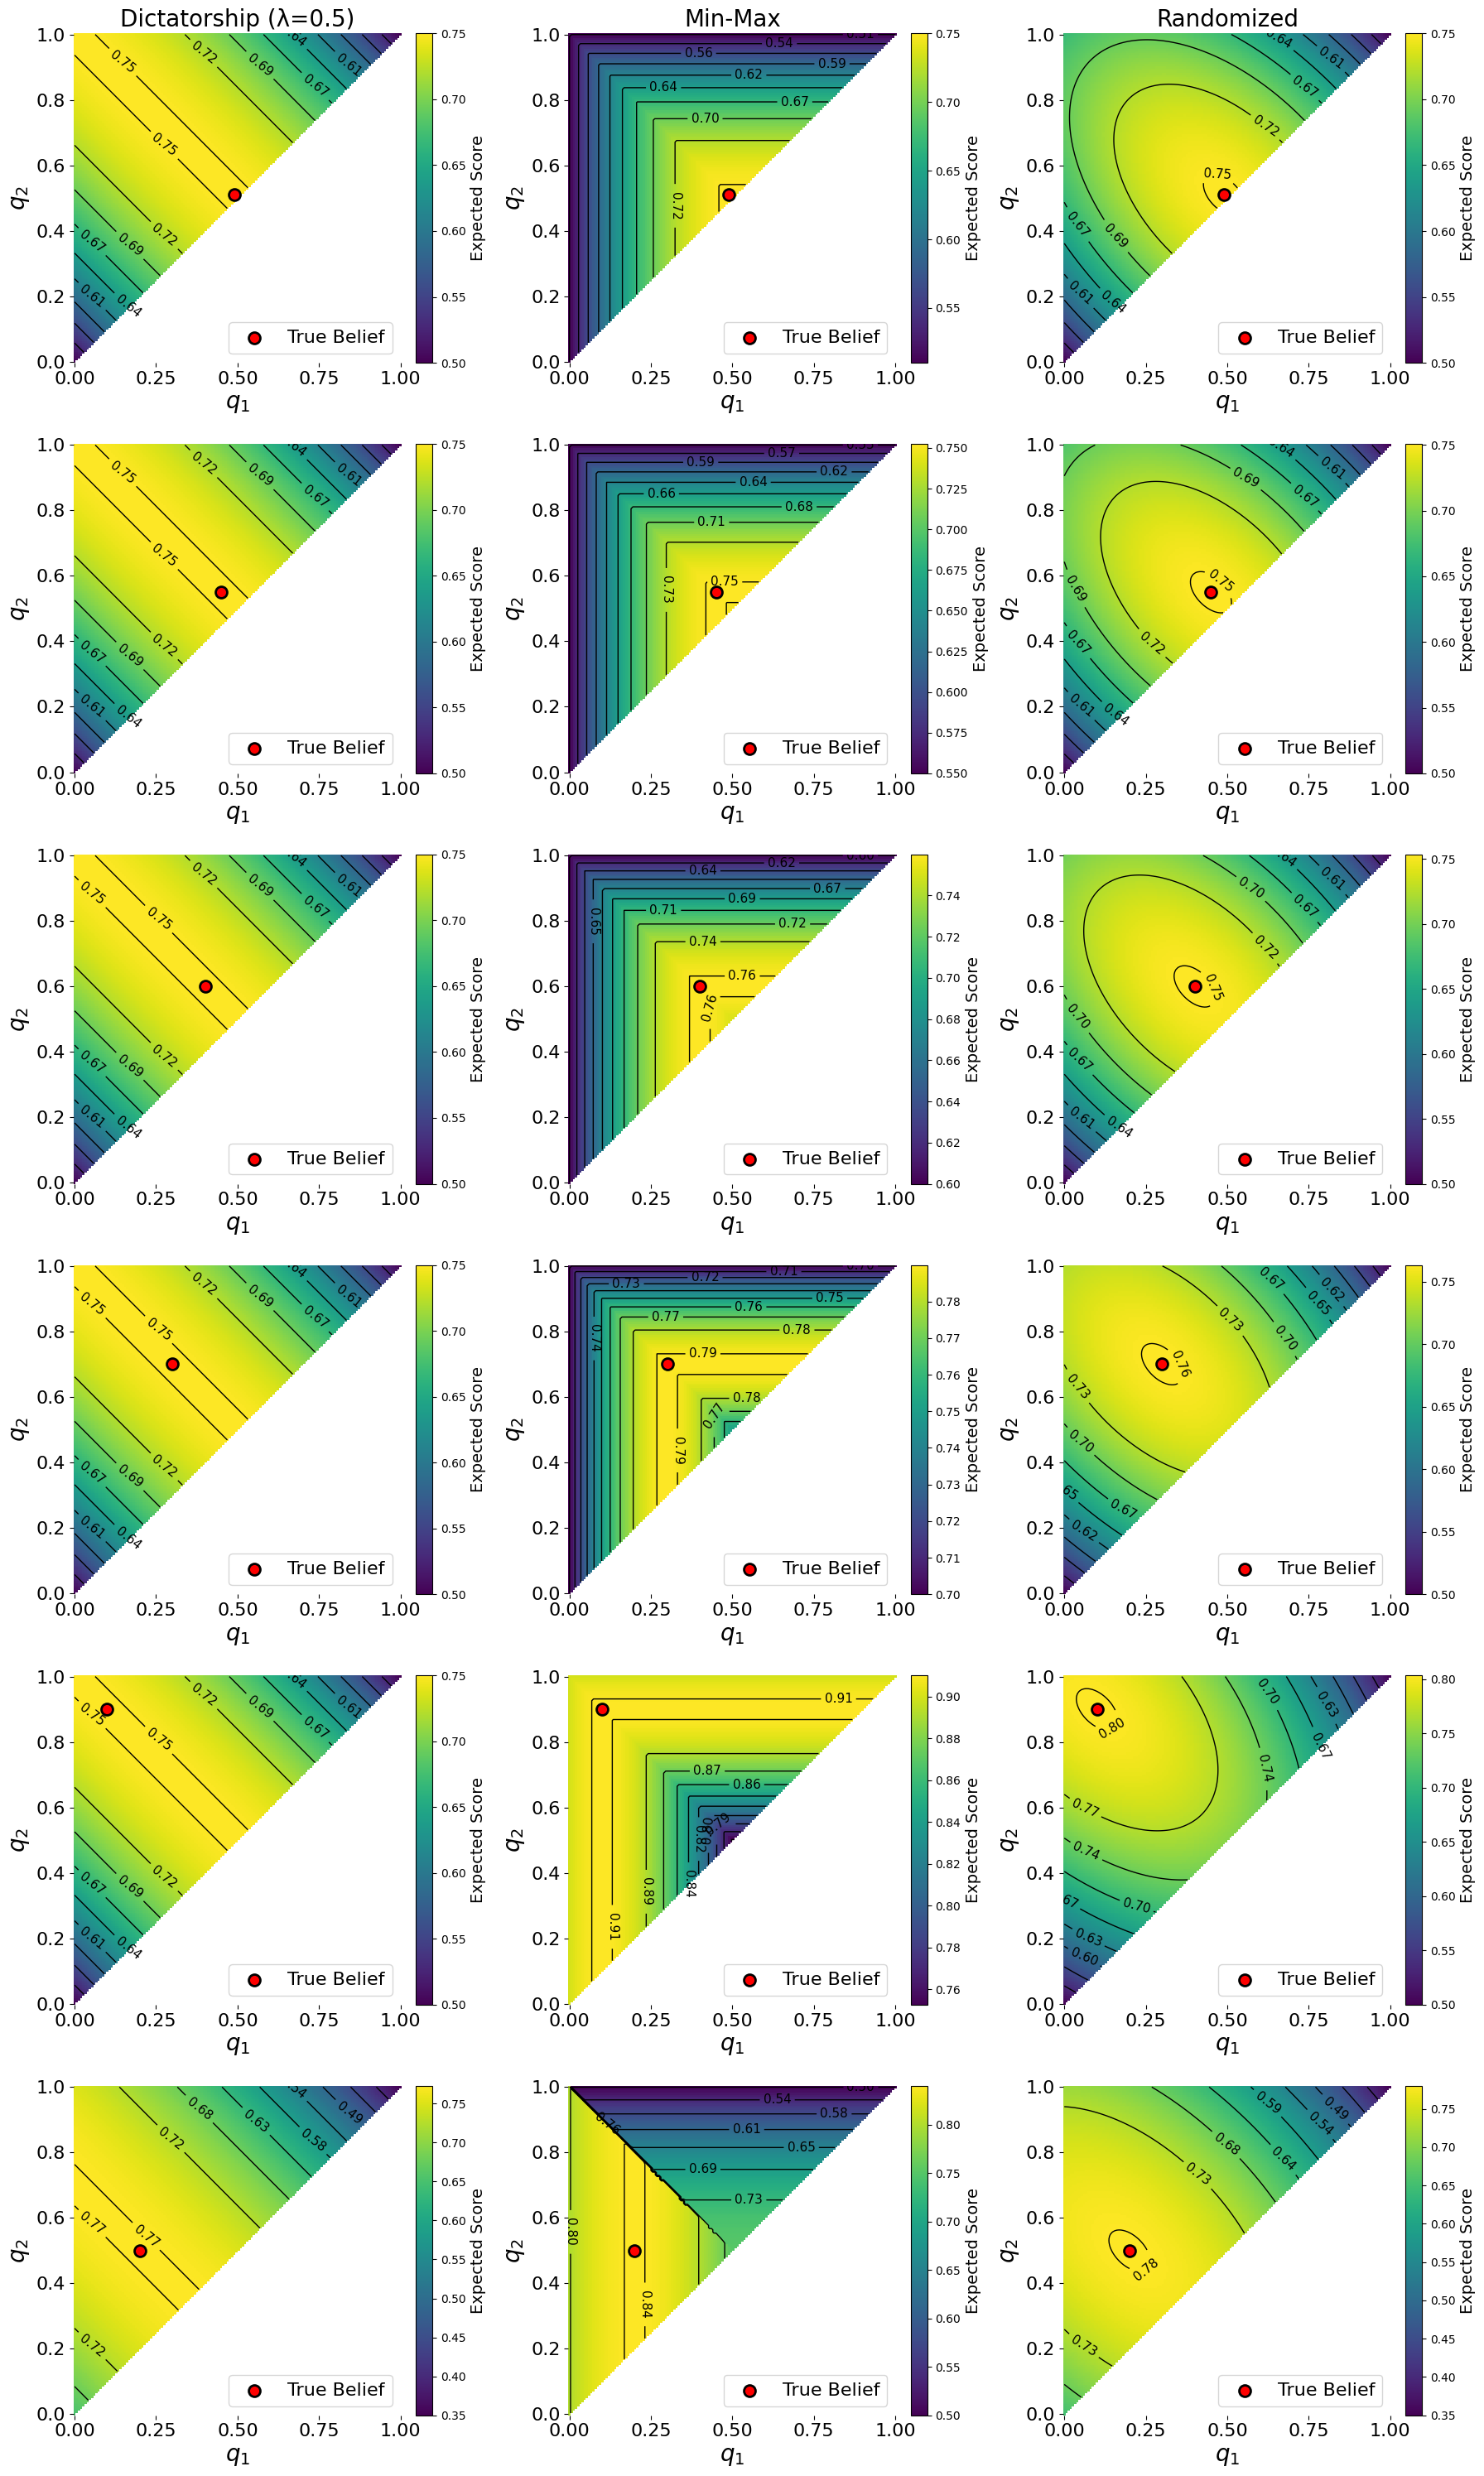

Saved: vary_beliefs_grid.pdf

Saving individual panels...
  saved very_narrow__dictatorship_0_5.pdf
  saved very_narrow__min_max.pdf
  saved very_narrow__randomized.pdf
  saved narrow__dictatorship_0_5.pdf
  saved narrow__min_max.pdf
  saved narrow__randomized.pdf
  saved medium__dictatorship_0_5.pdf
  saved medium__min_max.pdf
  saved medium__randomized.pdf
  saved wide__dictatorship_0_5.pdf
  saved wide__min_max.pdf
  saved wide__randomized.pdf
  saved very_wide__dictatorship_0_5.pdf
  saved very_wide__min_max.pdf
  saved very_wide__randomized.pdf
  saved asymmetric__dictatorship_0_5.pdf
  saved asymmetric__min_max.pdf
  saved asymmetric__randomized.pdf

Done: 1 grid + 18 individual panels in c:\Users\sahin\OneDrive\Belgeler\programming\Imprecise-Scoring-Rule-Seminar\figs


In [35]:
# Combined 6×3 grid
n_rows = len(BELIEF_SETTINGS)
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 5.0))
for row, (label, p_lo, p_hi) in enumerate(BELIEF_SETTINGS):
    for col, (method, score_fn) in enumerate(zip(METHOD_NAMES, SCORE_FUNCS)):
        print(f"  {label}  |  {method} ...")
        Z = score_fn(p_lo, p_hi)
        ax = axes[row, col]
        c = plot_panel(ax, Z, p_lo, p_hi, title=method if row == 0 else None)
        fig.colorbar(c, ax=ax, fraction=0.046, pad=0.04).set_label("Expected Score", fontsize=14)
plt.tight_layout(h_pad=2.0, w_pad=1.0)
fig.savefig(os.path.join(FIG_DIR, "vary_beliefs_grid.pdf"), bbox_inches="tight", dpi=150)
plt.show()
print("Saved: vary_beliefs_grid.pdf")

# Individual panels (for the presentation)
def _slug(s):
    s = re.sub(r"\[.*?\]", "", s.strip().lower())
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return s.strip("_")

print("\nSaving individual panels...")
for label, p_lo, p_hi in BELIEF_SETTINGS:
    interval_label = re.search(r"\[.*?\]", label).group(0)
    for method, score_fn in zip(METHOD_NAMES, SCORE_FUNCS):
        Z = score_fn(p_lo, p_hi)
        fig_i, ax_i = plt.subplots(figsize=(8, 6))
        c = plot_panel(ax_i, Z, p_lo, p_hi, title=f"{method}, {interval_label}")
        fig_i.colorbar(c, ax=ax_i).set_label("Expected Score", fontsize=20)
        plt.tight_layout()
        fname = f"{_slug(label)}__{_slug(method)}.pdf"
        fig_i.savefig(os.path.join(FIG_DIR, fname), bbox_inches="tight", dpi=150)
        plt.close(fig_i)
        print(f"  saved {fname}")
print(f"\nDone: 1 grid + {n_rows * 3} individual panels in {FIG_DIR}")

**Summary of findings:**

- **Dictatorship**: Score depends only on the weighted sum λ·q1 + (1-λ)·q2, so every (q1,q2) on the same iso-line scores identically. The honest report lies on a flat ridge so not strictly proper at any width.
- **Min-Max**: The optimal action collapses to one endpoint of the reported interval. Peak drifts away from the true belief increasingly as the interval widens so not strictly proper. Jagged appearance in some panels is a grid-resolution artifact where the DM's action switches abruptly.
- **Randomized**: In all 6 settings (narrow, wide, asymmetric), the red dot sits at the isolated peak. This makes Corollary 5.4 confirmed empirically across belief widths.

## Real Patient Triple (max-width credal set from real data)

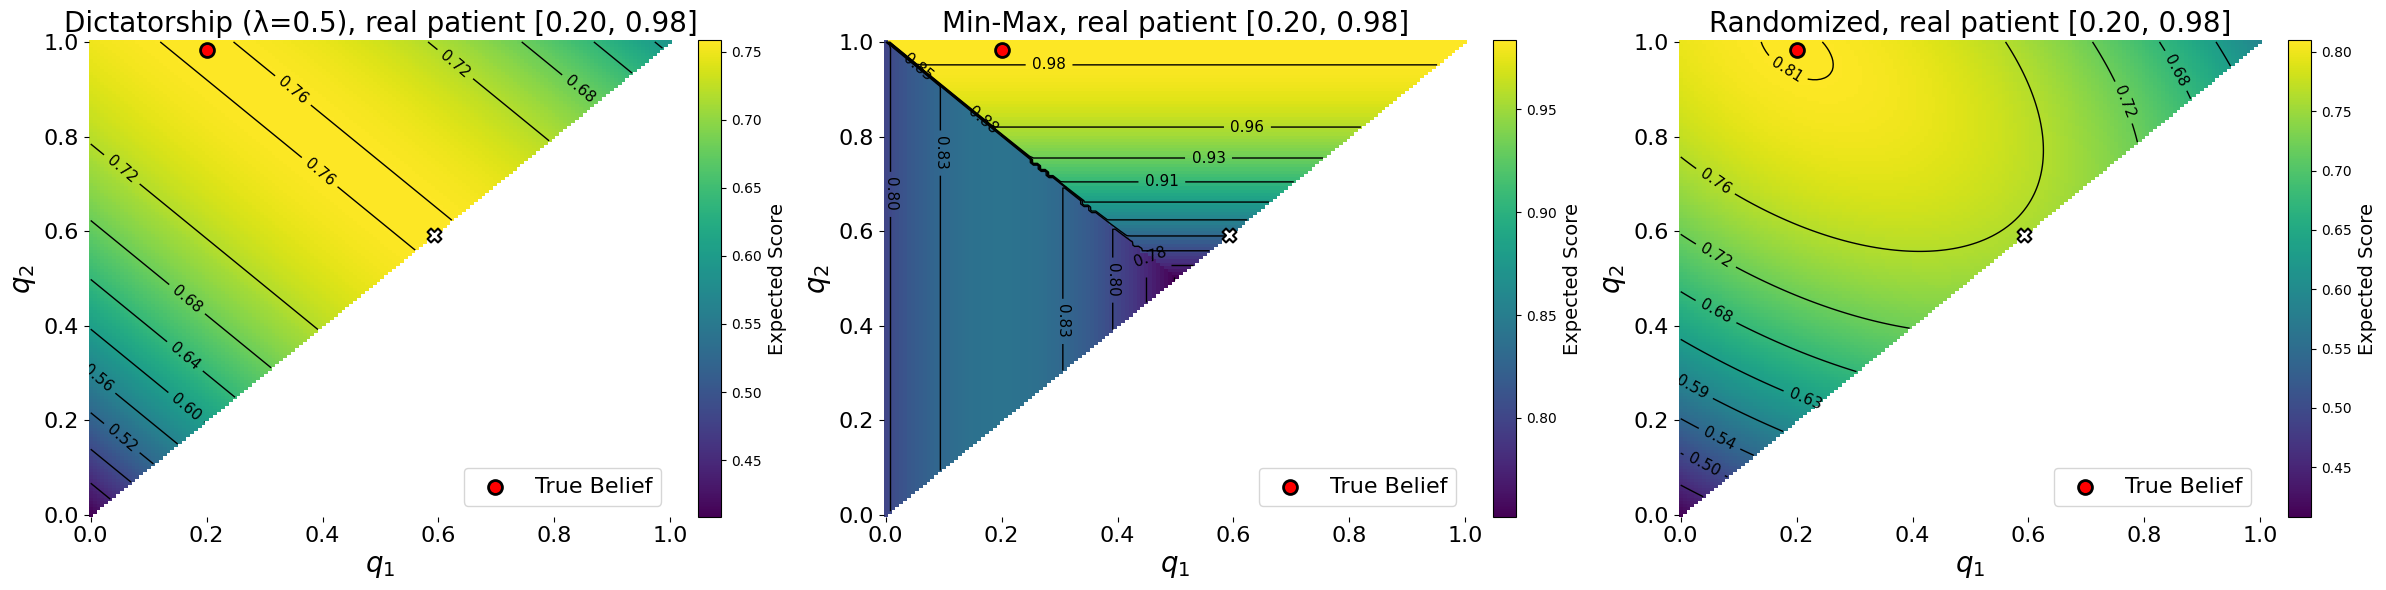

  saved real_patient__dictatorship_0_5.pdf
  saved real_patient__min_max.pdf
  saved real_patient__randomized.pdf


In [36]:
P_LOW, P_UP = 0.2000, 0.9832   # replace with printed max-width values from Part A
m = (P_LOW + P_UP) / 2

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for ax, (method, score_fn) in zip(axes, zip(METHOD_NAMES, SCORE_FUNCS)):
    Z = score_fn(P_LOW, P_UP)
    c = plot_panel(ax, Z, P_LOW, P_UP,
                   title=f"{method}, real patient [{P_LOW:.2f}, {P_UP:.2f}]")
    ax.scatter(m, m, color="white", marker="X", s=100,
               edgecolors="black", linewidth=1.5, zorder=6)
    fig.colorbar(c, ax=ax, fraction=0.046, pad=0.04).set_label("Expected Score", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "real_patient_triple.pdf"), bbox_inches="tight", dpi=150)
plt.show()

for method, score_fn in zip(METHOD_NAMES, SCORE_FUNCS):
    Z = score_fn(P_LOW, P_UP)
    fig_i, ax_i = plt.subplots(figsize=(8, 6))
    c = plot_panel(ax_i, Z, P_LOW, P_UP,
                   title=f"{method}, real patient [{P_LOW:.2f}, {P_UP:.2f}]")
    ax_i.scatter(m, m, color="white", marker="X", s=100,
                 edgecolors="black", linewidth=1.5, zorder=6)
    fig_i.colorbar(c, ax=ax_i).set_label("Expected Score", fontsize=20)
    plt.tight_layout()
    fname = f"real_patient__{_slug(method)}.pdf"
    fig_i.savefig(os.path.join(FIG_DIR, fname), bbox_inches="tight", dpi=150)
    plt.close(fig_i)
    print(f"  saved {fname}")

## Probe Plot: Let's show why Randomization Works

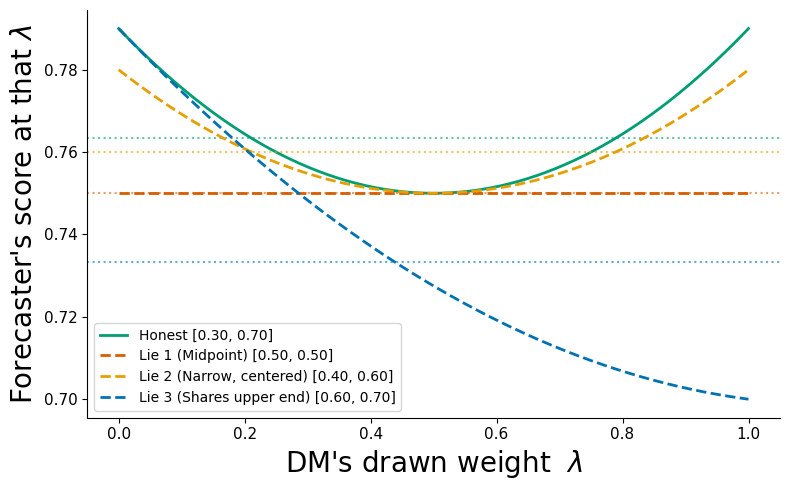

In [37]:
P_LOW, P_UP = 0.30, 0.70
m = (P_LOW + P_UP) / 2

reports = {
    "Honest [0.30, 0.70]": (0.30, 0.70, COLORS["green"], "-"),
    "Lie 1 (Midpoint) [0.50, 0.50]": (0.50, 0.50, COLORS["red"], "--"),
    "Lie 2 (Narrow, centered) [0.40, 0.60]": (0.40, 0.60, COLORS["orange"], "--"),
    "Lie 3 (Shares upper end) [0.60, 0.70]": (0.60, 0.70, COLORS["blue"], "--"),
}

lams = np.linspace(0, 1, 200)

def score_at_lambda(q1, q2, lam):
    true_p = lam * P_LOW + (1 - lam) * P_UP
    a      = lam * q1 + (1 - lam) * q2
    score  = (1 - true_p) * _loss(a, 0.0) + true_p * _loss(a, 1.0)
    return -score

fig, ax = plt.subplots(figsize=(8, 5))
for label, (q1, q2, color, ls) in reports.items():
    ys = [score_at_lambda(q1, q2, lam) for lam in lams]
    ax.plot(lams, ys, color=color, linestyle=ls, linewidth=2, label=label)
    ax.axhline(np.mean(ys), color=color, linestyle=":", linewidth=1.5, alpha=0.6)
ax.set_xlabel(r"DM's drawn weight  $\lambda$", fontsize=20)
ax.set_ylabel("Forecaster's score at that $\\lambda$", fontsize=20)
ax.legend(fontsize=10, loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "probe_plot.pdf"), bbox_inches="tight", dpi=150)
plt.show()

- Green (honest) sits on or above every lie at every λ.
- Each lie touches honesty at a different single λ (midpoint lie at λ=½; the upper-sharing lie at λ=0) and falls below everywhere else.
- Dotted horizontal lines are each report's average over λ. The green average is strictly highest and we can say that gap is the strict-properness margin.

## Support Degradation: 1D Score vs Reported Width

Fixes the midpoint at 0.5, varies reported width from 0 to 1, and plots the randomized score under three λ-support regimes. Shows how Var(λ) controls the sharpness of the incentive.

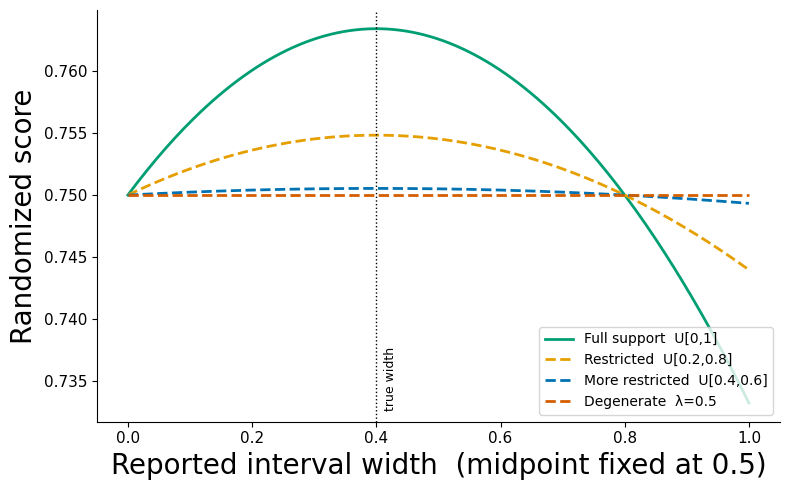

In [38]:
P_LOW, P_UP = 0.30, 0.70
honest_width = P_UP - P_LOW   # 0.4
MID = 0.5
widths = np.linspace(0.0, 1.0, 200)

supports = [
    ("Full support  U[0,1]", 0.0, 1.0, COLORS["green"],  "-"),
    ("Restricted  U[0.2,0.8]", 0.2, 0.8, COLORS["orange"], "--"),
    ("More restricted  U[0.4,0.6]", 0.4, 0.6, COLORS["blue"],   "--"),
    ("Degenerate  λ=0.5", 0.5, 0.5, COLORS["red"],    "--"),
]

def rand_score_point(q1, q2, lam_min, lam_max, n=500):
    lams   = np.linspace(lam_min, lam_max, n + 1)
    true_p = lams * P_LOW + (1 - lams) * P_UP
    a      = lams * q1 + (1 - lams) * q2
    s      = (1 - true_p) * _loss(a, 0.0) + true_p * _loss(a, 1.0)
    return np.mean(-s)

fig, ax = plt.subplots(figsize=(8, 5))
for label, lmin, lmax, color, ls in supports:
    ys = []
    for w in widths:
        q1 = max(0.0, MID - w / 2)
        q2 = min(1.0, MID + w / 2)
        ys.append(rand_score_point(q1, q2, lmin, lmax))
    ax.plot(widths, ys, color=color, linestyle=ls, linewidth=2, label=label)
ax.axvline(honest_width, color="black", linestyle=":", linewidth=1)
ax.text(honest_width + 0.012, ax.get_ylim()[0] + 0.006, "true width",
        rotation=90, va="top", ha="left", fontsize=9, color="black")
ax.set_xlabel("Reported interval width  (midpoint fixed at 0.5)", fontsize=20)
ax.set_ylabel("Randomized score", fontsize=20)
ax.legend(fontsize=10, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "support_degradation_1d.pdf"), bbox_inches="tight", dpi=150)
plt.show()

The green peak (full support) is sharpest; restricting the λ range flattens it progressively (orange U[0.2,0.8], then blue U[0.4,0.6] which is nearly flat); dictatorship (red, λ fixed) is completely flat. Var(λ)=0, no incentive at all. The vertical dotted line marks the true width 0.4.

## Full-Support Necessity: Contour Triple

Same belief `[0.30, 0.70]` under three λ-support regimes. Shows that shrinking support flattens the peak without moving it. Which means strict properness degrades continuously into dictatorship.

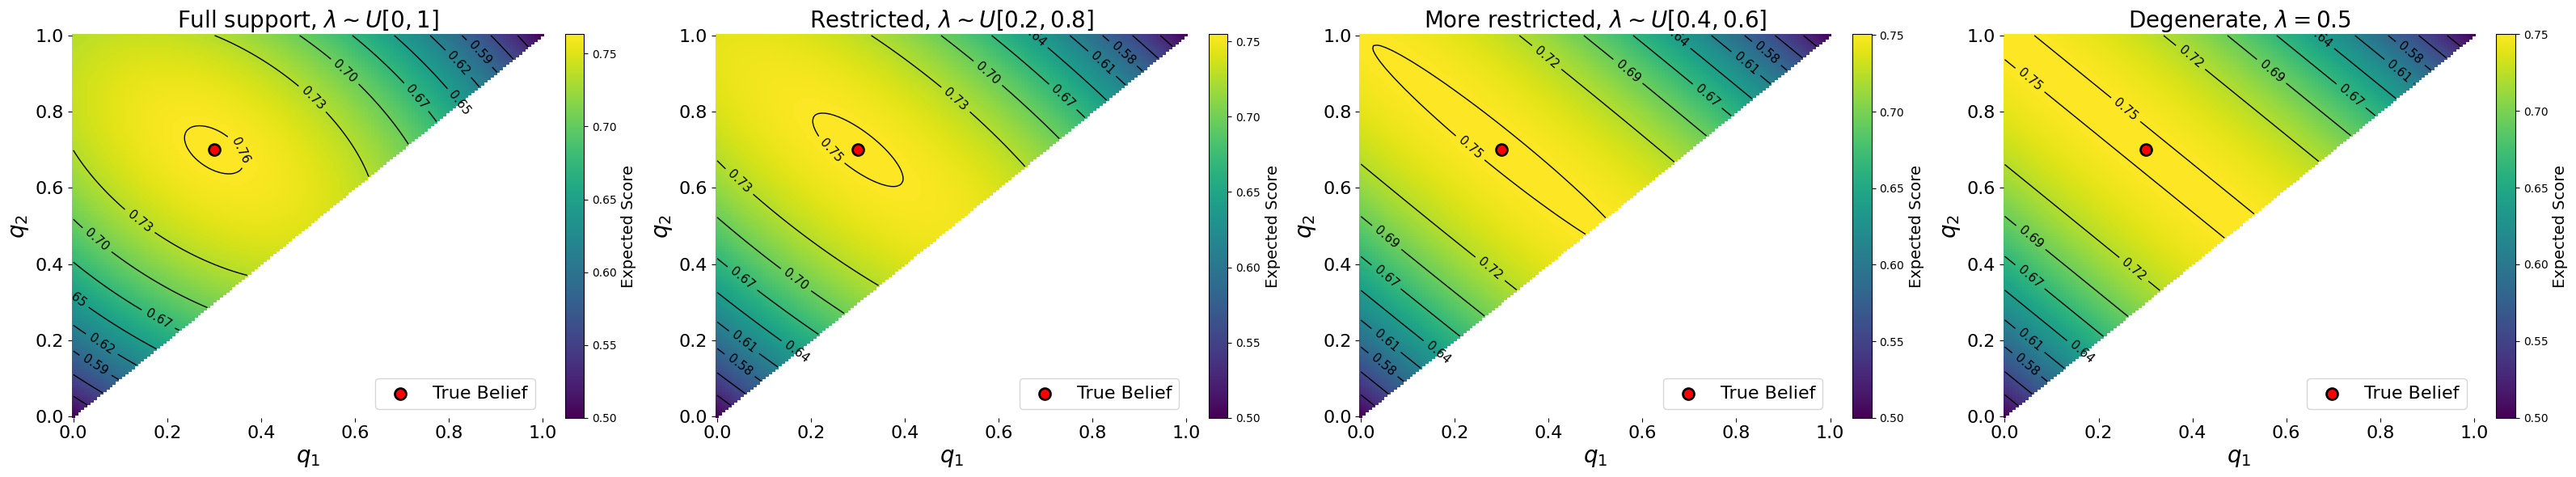

  saved support_full.pdf
  saved support_restricted.pdf
  saved support_restricted_narrow.pdf
  saved support_degenerate.pdf


In [39]:
def score_randomized_support(p_low, p_up, lam_min, lam_max, n=NUM_AGG_SAMPLES):
    """Randomized score with λ drawn only from [lam_min, lam_max]."""
    Z = np.zeros_like(Q1, dtype=np.float64)
    weights = np.linspace(lam_min, lam_max, n + 1)
    for w in weights:
        true_p = w * p_low + (1 - w) * p_up
        a = w * Q1 + (1 - w) * Q2
        score = (1 - true_p) * _loss(a, 0.0) + true_p * _loss(a, 1.0)
        Z += -score
    return np.where(VALID, Z / (n + 1), np.nan)

P_LOW, P_UP = 0.30, 0.70
panels = [
    ("Full support, $\\lambda\\sim U[0,1]$", 0.0, 1.0, "support_full"),
    ("Restricted, $\\lambda\\sim U[0.2,0.8]$", 0.2, 0.8, "support_restricted"),
    ("More restricted, $\\lambda\\sim U[0.4,0.6]$", 0.4, 0.6, "support_restricted_narrow"),
    ("Degenerate, $\\lambda=0.5$", 0.5, 0.5, "support_degenerate"),
]

# Combined sequence (4 panels)
fig, axes = plt.subplots(1, 4, figsize=(32, 6))
for ax, (label, lmin, lmax, _) in zip(axes, panels):
    Z = score_randomized_support(P_LOW, P_UP, lmin, lmax)
    c = plot_panel(ax, Z, P_LOW, P_UP, title=label)
    fig.colorbar(c, ax=ax, fraction=0.046, pad=0.04).set_label("Expected Score", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "full_support_necessity.pdf"), bbox_inches="tight", dpi=150)
plt.show()

# Individual panels
for label, lmin, lmax, fname in panels:
    Z = score_randomized_support(P_LOW, P_UP, lmin, lmax)
    fig_i, ax_i = plt.subplots(figsize=(8, 6))
    c = plot_panel(ax_i, Z, P_LOW, P_UP, title=label)
    fig_i.colorbar(c, ax=ax_i).set_label("Expected Score", fontsize=20)
    plt.tight_layout()
    fig_i.savefig(os.path.join(FIG_DIR, f"{fname}.pdf"), bbox_inches="tight", dpi=150)
    plt.close(fig_i)
    print(f"  saved {fname}.pdf")